# Определение стоимости автомобилей

Сервис по продаже автомобилей с пробегом разрабатывает приложение для привлечения новых клиентов. В нём можно быстро узнать рыночную стоимость своего автомобиля. В нашем распоряжении исторические данные: технические характеристики, комплектации и цены автомобилей. Нужно построить модель для определения стоимости. 

Заказчику важны:

- качество предсказания;
- скорость предсказания;
- время обучения.

## Подготовка данных

### Загрузим данные и посмотрим на предварительную информацию о датасетах

In [1]:
#установки
!pip install shap
!pip install phik
!pip install scikit-learn==1.5.2

In [2]:
# Импорт стандартных библиотек
import pandas as pd
import numpy as np

# Импорт библиотек для визуализации
import matplotlib.pyplot as plt
import seaborn as sns

# Импорт библиотек для машинного обучения и обработки данных
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix, mean_squared_error
from sklearn.dummy import DummyRegressor
from sklearn.tree import  DecisionTreeRegressor
from lightgbm import LGBMRegressor

# Импорт библиотек для анализа данных
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

import phik
import time
import shap
from datetime import datetime
from time import time

Посмотрим всю предварительную информацию о датасете

In [4]:
def analyze_dataset(dataset):
    for i, df in enumerate(dataset):
        #выведем первые строки
        print(f"First rows of dataset {i}:")
        print(df.head())
        print('\n')
        #выведем информацию о датасете
        print(f'Info o dataset {i}:')
        print(df.info())
        print('\n')
        #проверим наличие пропусков 
        print(f'Missing values in dataset {i}:')
        print(df.isna().sum())
        print('\n')
        #проверим наличие дубликатов
        print(f'Duplicate rows in dataset {i}:')
        print(df.duplicated().sum())
        print('/n')
#загруженный датасет
dataset = [data]
#запустим функцию для анализа
analyze_dataset(dataset)

First rows of dataset 0:
           DateCrawled  Price VehicleType  RegistrationYear Gearbox  Power  \
0  2016-03-24 11:52:17    480         NaN              1993  manual      0   
1  2016-03-24 10:58:45  18300       coupe              2011  manual    190   
2  2016-03-14 12:52:21   9800         suv              2004    auto    163   
3  2016-03-17 16:54:04   1500       small              2001  manual     75   
4  2016-03-31 17:25:20   3600       small              2008  manual     69   

   Model  Kilometer  RegistrationMonth  FuelType       Brand Repaired  \
0   golf     150000                  0    petrol  volkswagen      NaN   
1    NaN     125000                  5  gasoline        audi      yes   
2  grand     125000                  8  gasoline        jeep      NaN   
3   golf     150000                  6    petrol  volkswagen       no   
4  fabia      90000                  7  gasoline       skoda       no   

           DateCreated  NumberOfPictures  PostalCode             La

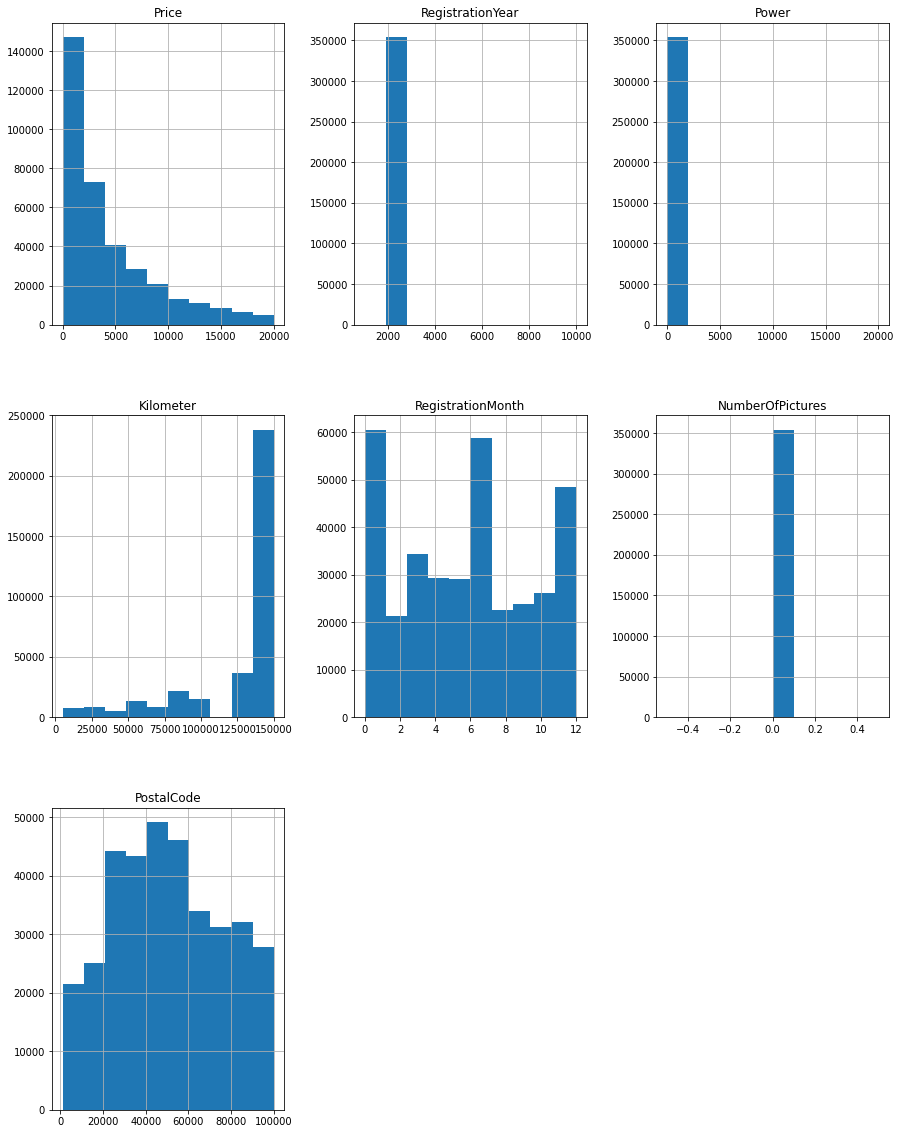

In [5]:
data.hist(figsize=(15, 20));

Данные датафрейма представляют собой таблицу с 354369 записями и 16 столбцами. 7 столбцов имеют числовой тип данных (int64), остальные 9 - строковый тип данных (object). Тип данных некоторых столбцов не соответствует информации, представленной в них. DateCrawled (int), DateCreated (object), LastSeen (object) возможно потребуется привести к форме datetime. На основе предоставленной информации, мы можем отметить необходимость дополнительной обработки данных, поскольку есть пропущенные данные в столбцах (VehicleType (37490), Gearbox (19833), Model (19705), FuelType (32895), Repaired (71154)).Также, нужно будет привести названия столбцов к нижнему регистру и правильной стилистике. Количество явных дубликатов - 4, которые также удалим.

### Обозначения столбцов 

In [6]:
data.head(2)

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,2016-03-24 11:52:17,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50


Приведем к правильной стилистике обозначения столбцов

In [7]:
#сначала все обозначения приведем к нижнему регистру
data.columns = data.columns.str.lower()

In [8]:
#проверим
data.head(2)

,datecrawled,price,vehicletype,registrationyear,gearbox,power,model,kilometer,registrationmonth,fueltype,brand,repaired,datecreated,numberofpictures,postalcode,lastseen
0,2016-03-24 11:52:17,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50


In [9]:
#теперь разделим слова с помощью нижнего подчеркивания
data = data.rename(columns = {'datecrawled':'date_crawled', 'vehicletype': 'vehicle_type', 'registrationyear':'registration_year', 'registrationmonth': 'registration_month', 'fueltype': 'fuel_type', 'datecreated':'date_created', 'numberofpictures':'number_of_pictures', 'postalcode':'postal_code', 'lastseen':'last_seen'})

In [10]:
#проверим
data.head(2)

,date_crawled,price,vehicle_type,registration_year,gearbox,power,model,kilometer,registration_month,fuel_type,brand,repaired,date_created,number_of_pictures,postal_code,last_seen
0,2016-03-24 11:52:17,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50


### Изменение типа данных

In [11]:
#Изменим тип данных с int64 и object для столбцов DateCrawled, DateCreated, LastSeen
data['date_crawled'] = pd.to_datetime(data['date_crawled'], format = '%Y-%m-%dT%H:%M:%S')
data['date_created'] = pd.to_datetime(data['date_created'], format = '%Y-%m-%dT%H:%M:%S')
data['last_seen'] = pd.to_datetime(data['last_seen'], format = '%Y-%m-%dT%H:%M:%S')

Информация столбца postal_code может дать географическую привязку данных, поскольку цена может отличаться в зависимости от региона. Однако, в числовом формате обрабатывать такую информацию будет нецелесообразно. Если мы приведем в формат object, то в исходном виде кодировщики будут данную информацию обрабатывать огромное количество времени, поэтому попробуем оставим только первые 2 цифры и сделаем новый столбец  postal_region'

In [12]:
# Преобразуем почтовые коды в укрупненные регионы (первые 2 цифры)
data['postal_region'] = data['postal_code'].astype(str).str[:2]

In [13]:
#проверим информацию о датафрейме
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   date_crawled        354369 non-null  datetime64[ns]
 1   price               354369 non-null  int64         
 2   vehicle_type        316879 non-null  object        
 3   registration_year   354369 non-null  int64         
 4   gearbox             334536 non-null  object        
 5   power               354369 non-null  int64         
 6   model               334664 non-null  object        
 7   kilometer           354369 non-null  int64         
 8   registration_month  354369 non-null  int64         
 9   fuel_type           321474 non-null  object        
 10  brand               354369 non-null  object        
 11  repaired            283215 non-null  object        
 12  date_created        354369 non-null  datetime64[ns]
 13  number_of_pictures  354369 no

### Обработка пропусков

Заполнение пропусков в столбце 'repaired' простым использованием наиболее частого значения (mode()) может быть не самым правильным решением. Более аккуратные подходы включают использование дополнительной категории, например unknown, предсказание значения на основе других признаков или применение модели машинного обучения.

Попробуем все же ввести 3-ю категорию unknown

In [14]:
data['repaired'].fillna('unknown', inplace=True)

In [15]:
#проверим
data.isna().sum()

date_crawled              0
price                     0
vehicle_type          37490
registration_year         0
gearbox               19833
power                     0
model                 19705
kilometer                 0
registration_month        0
fuel_type             32895
brand                     0
repaired                  0
date_created              0
number_of_pictures        0
postal_code               0
last_seen                 0
postal_region             0
dtype: int64

Заполнить пропуски в столбцах vehicle_type, gearbox и fuel_type попробуем, используя одинаковые значения в столбцах model (модель автомобиля) и brand (марка автомобиля). Это предполагает, что для одинаковых моделей и марок автомобилей обычно характерны схожие значения этих признаков. Мы можем сгруппировать данные по model и brand и для каждой группы заполнить пропуски на основе наиболее часто встречающегося значения в этой группе.

In [16]:
#напишем функцию для заполнения пропусков на основе Mode (самого частого значения)
def fill_missing_values(group, columns):
    for column in columns:
        # Заполняем пропуски в каждом столбце самым частым значением в группе
        group[column].fillna(group[column].mode()[0], inplace=True)
    return group

# предоставим список столбцов, где есть пропуски, которые нужно заполнить
columns_to_fill = ['vehicle_type', 'gearbox', 'fuel_type']

# Применим функцию заполнения для каждой группы Model и Brand
data = data.groupby(['model', 'brand']).apply(lambda group: fill_missing_values(group, columns_to_fill))

# Убедимся, что пропуски заполнены
print(data.isna().sum())

date_crawled          0
price                 0
vehicle_type          0
registration_year     0
gearbox               0
power                 0
model                 0
kilometer             0
registration_month    0
fuel_type             0
brand                 0
repaired              0
date_created          0
number_of_pictures    0
postal_code           0
last_seen             0
postal_region         0
dtype: int64


Все пропуски обработаны

### Удаление дубликатов

Проверим наличие явных дубликатов

In [17]:
data.duplicated().sum()

4

In [18]:
data = data.drop_duplicates().reset_index(drop=True)

In [19]:
data.duplicated().sum()

0

От явных дубликатов избавились

### Проверка уникальности данных категориальных переменных

In [20]:
#проверим категории столбца 'vehicle_type' на уникальность
data['vehicle_type'].unique()

array(['sedan', 'suv', 'small', 'convertible', 'bus', 'wagon', 'coupe',
       'other'], dtype=object)

В нашем списке типов кузова для автомобилей: 'sedan' (седан), 'suv' (внедорожник), 'small' (малый), 'convertible' (кабриолет), 'bus' (автобус), 'wagon' (универсал), 'coupe' (купе),'other' (другие) нет явных дубликатов.

In [21]:
#проверим категории столбца 'gearbox' на уникальность
data['gearbox'].unique()

array(['manual', 'auto'], dtype=object)

В датасете 2 типа коробки передач: manual (механическая), auto (автоматическая)

In [22]:
#проверим категории столбца 'model' на уникальность
data['model'].unique()

array(['golf', 'grand', 'fabia', '3er', '2_reihe', 'other', 'c_max',
       '3_reihe', 'passat', 'navara', 'ka', 'polo', 'twingo', 'a_klasse',
       'scirocco', '5er', 'meriva', 'arosa', 'c4', 'civic', 'transporter',
       'punto', 'e_klasse', 'clio', 'kadett', 'kangoo', 'corsa', 'one',
       'fortwo', '1er', 'b_klasse', 'signum', 'astra', 'a8', 'jetta',
       'fiesta', 'c_klasse', 'micra', 'vito', 'sprinter', '156', 'escort',
       'forester', 'xc_reihe', 'scenic', 'a4', 'a1', 'insignia', 'combo',
       'focus', 'tt', 'a6', 'jazz', 'omega', 'slk', '7er', '80', '147',
       '100', 'z_reihe', 'sportage', 'sorento', 'v40', 'ibiza', 'mustang',
       'eos', 'touran', 'getz', 'a3', 'almera', 'megane', 'lupo', 'r19',
       'zafira', 'caddy', 'mondeo', 'cordoba', 'colt', 'impreza',
       'vectra', 'berlingo', 'tiguan', 'i_reihe', 'espace', 'sharan',
       '6_reihe', 'panda', 'up', 'seicento', 'ceed', '5_reihe', 'yeti',
       'octavia', 'mii', 'rx_reihe', '6er', 'modus', 'fox', 'ma

In [23]:
#проверим категории столбца 'fuel_type' на уникальность
data['fuel_type'].unique()

array(['petrol', 'gasoline', 'lpg', 'other', 'hybrid', 'cng', 'electric'],
      dtype=object)

In [24]:
data['fuel_type'].value_counts()

petrol      227992
gasoline    100755
lpg           4962
cng            544
hybrid         208
other          133
electric        66
Name: fuel_type, dtype: int64

В датасете представлены следующие типы топлива: Petrol, gasoline (Бензин), LPG (Сжиженный газ), Hybrid (Гибрид), CNG (Сжатый природный газ), Electric (Электрический) и Other (Другое).

Petrol и  gasoline это разные названия бензина. Поэтому возьмем одно название 'gasoline' и объединим эти категории.

In [25]:
data['fuel_type'] = data['fuel_type'].replace('petrol', 'gasoline')

In [26]:
# проверим
data['fuel_type'].value_counts()

gasoline    328747
lpg           4962
cng            544
hybrid         208
other          133
electric        66
Name: fuel_type, dtype: int64

In [27]:
#проверим категории столбца 'brand' на уникальность
data['brand'].unique()

array(['volkswagen', 'jeep', 'skoda', 'bmw', 'peugeot', 'ford', 'mazda',
       'nissan', 'renault', 'mercedes_benz', 'opel', 'seat', 'citroen',
       'honda', 'fiat', 'mini', 'smart', 'hyundai', 'audi', 'alfa_romeo',
       'subaru', 'volvo', 'mitsubishi', 'kia', 'suzuki', 'lancia',
       'toyota', 'chevrolet', 'dacia', 'daihatsu', 'chrysler', 'jaguar',
       'daewoo', 'porsche', 'rover', 'saab', 'land_rover', 'trabant',
       'lada'], dtype=object)

In [28]:
#проверим категории столбца 'repaired' на уникальность
data['repaired'].unique()

array(['unknown', 'no', 'yes'], dtype=object)

### Создание нового категориального признака

У нас разный возраст машин. Есть гипотеза, что для разных возрастов - своё ценообразование. Поэтому, можно попробовать ввести фактор "тип возраста" (ретро, супер-ретро, старая, новая)

In [29]:
# Получим текущий год
current_year = datetime.now().year

# Вычислим возраст автомобиля
data['age_years'] = current_year - data['registration_year']

# напишем функцию для определения типа возраста
def categorize_age(age):
    if age < 3:
        return 'New'
    elif 3 <= age < 10:
        return 'Old'
    elif 10 <= age < 30:
        return 'Retro'
    else:
        return 'Super-Retro'

# Применение функции к колонке age_years
data['age_category'] = data['age_years'].apply(categorize_age)

In [30]:
current_year

2024

In [31]:
data.head()

,date_crawled,price,vehicle_type,registration_year,gearbox,power,model,kilometer,registration_month,fuel_type,brand,repaired,date_created,number_of_pictures,postal_code,last_seen,postal_region,age_years,age_category
0,2016-03-24 11:52:17,480,sedan,1993,manual,0,golf,150000,0,gasoline,volkswagen,unknown,2016-03-24,0,70435,2016-04-07 03:16:57,70,31,Super-Retro
1,2016-03-14 12:52:21,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,unknown,2016-03-14,0,90480,2016-04-05 12:47:46,90,20,Retro
2,2016-03-17 16:54:04,1500,small,2001,manual,75,golf,150000,6,gasoline,volkswagen,no,2016-03-17,0,91074,2016-03-17 17:40:17,91,23,Retro
3,2016-03-31 17:25:20,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,2016-03-31,0,60437,2016-04-06 10:17:21,60,16,Retro
4,2016-04-04 17:36:23,650,sedan,1995,manual,102,3er,150000,10,gasoline,bmw,yes,2016-04-04,0,33775,2016-04-06 19:17:07,33,29,Retro


In [32]:
data.query('age_years <0')

,date_crawled,price,vehicle_type,registration_year,gearbox,power,model,kilometer,registration_month,fuel_type,brand,repaired,date_created,number_of_pictures,postal_code,last_seen,postal_region,age_years,age_category
12260,2016-03-29 18:39:40,49,sedan,5000,manual,0,golf,5000,12,gasoline,volkswagen,unknown,2016-03-29,0,74523,2016-04-06 04:16:14,74,-2976,New
16363,2016-03-23 16:43:29,700,suv,9999,manual,0,other,10000,0,gasoline,opel,unknown,2016-03-23,0,21769,2016-04-05 20:16:15,21,-7975,New
17296,2016-03-16 20:37:54,300,small,2200,manual,0,twingo,5000,12,gasoline,renault,unknown,2016-03-16,0,45307,2016-04-07 06:45:32,45,-176,New
24949,2016-03-07 20:50:57,150,sedan,3000,manual,0,a_klasse,5000,0,gasoline,mercedes_benz,unknown,2016-03-07,0,28217,2016-03-08 07:46:23,28,-976,New
25112,2016-03-24 17:45:47,800,bus,2066,manual,0,zafira,5000,0,gasoline,opel,unknown,2016-03-24,0,45355,2016-03-29 03:16:49,45,-42,New
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
313273,2016-03-28 19:39:11,99,sedan,9999,manual,0,1er,10000,0,gasoline,bmw,unknown,2016-03-28,0,1239,2016-04-07 01:45:47,12,-7975,New
316297,2016-03-20 17:53:51,12000,sedan,4000,manual,500,golf,5000,0,gasoline,volkswagen,no,2016-03-20,0,57392,2016-04-07 00:46:30,57,-1976,New
317020,2016-03-09 07:01:27,0,small,7500,manual,0,other,10000,0,gasoline,mini,no,2016-03-09,0,9669,2016-03-19 19:44:50,96,-5476,New
319958,2016-03-24 19:49:36,50,sedan,3000,manual,3000,golf,100000,6,gasoline,volkswagen,yes,2016-03-24,0,23992,2016-04-03 13:17:57,23,-976,New


Судя по всему, в некоторых данных в стобце registration_year есть некорректные записи, которые привели к отрицательным значениям в age_years, которые потом скорее всего нужно будет убрать из анализа

 ### Статистический анализ данных

Далее проведем исследовательский анализ данных

In [33]:
data.describe()

,price,registration_year,power,kilometer,registration_month,number_of_pictures,postal_code,age_years
count,334660.000000,334660.000000,334660.000000,334660.000000,334660.000000,334660.0,334660.000000,334660.000000
mean,4504.372249,2003.924024,111.372659,128562.795076,5.806075,0.0,50671.327365,20.075976
std,4531.457109,69.377633,185.157391,37205.638630,3.689157,0.0,25754.527341,69.377633
min,0.000000,1000.000000,0.000000,5000.000000,0.000000,0.0,1067.000000,-7975.000000
25%,1150.000000,1999.000000,70.000000,125000.000000,3.000000,0.0,30419.000000,16.000000
50%,2800.000000,2003.000000,105.000000,150000.000000,6.000000,0.0,49525.000000,21.000000
75%,6500.000000,2008.000000,143.000000,150000.000000,9.000000,0.0,71229.000000,25.000000
max,20000.000000,9999.000000,20000.000000,150000.000000,12.000000,0.0,99998.000000,1024.000000


Судя повсему, средняя стоимость автомобиля составляет 4504 евро с стандартным отклонением 4531 евро (что даже выше среднего значения). Значения варьируются от 0 ?(что странно) до 20 000 евро. 75% данных имеют стоимость до 6500 евро. Средняя мощность автомобиля составляет 111.37 л.с с стандартным отклонением 185 л.с. Значения варьируются от 0 (опять у нас нулевые значение) до 20000 л.с. Средний пробег автомобиля составляет 125562 км. Значения варьируются от 5000 до 150000 км. 75% данные имеют пробег до 150000 км. В столбце number_of_pictures все значения = 0. Видимо, никто не предоставил эти данные и в дальнейщем удалим этот столбец, поскольку он не несет никакой информации для нас. В столбце age_years средний срок службы составляет 20 лет. Значения варьируются от -7975 (это произошло из-за некорректного заполнения данных в столбце registration_year) до 1024 лет. 75% данные имеют срок службы до 25 лет.

###  Визуализация и анализ количественных и категориальных признаков¶

#### Визуализация и анализ количественных признаков

In [34]:
data.head(2)

,date_crawled,price,vehicle_type,registration_year,gearbox,power,model,kilometer,registration_month,fuel_type,brand,repaired,date_created,number_of_pictures,postal_code,last_seen,postal_region,age_years,age_category
0,2016-03-24 11:52:17,480,sedan,1993,manual,0,golf,150000,0,gasoline,volkswagen,unknown,2016-03-24,0,70435,2016-04-07 03:16:57,70,31,Super-Retro
1,2016-03-14 12:52:21,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,unknown,2016-03-14,0,90480,2016-04-05 12:47:46,90,20,Retro


In [35]:
#укажем столбцы с количественными данными, исключив дискретные и неинформативные
quantitative_columns = ['price', 'power', 'kilometer', 'age_years']

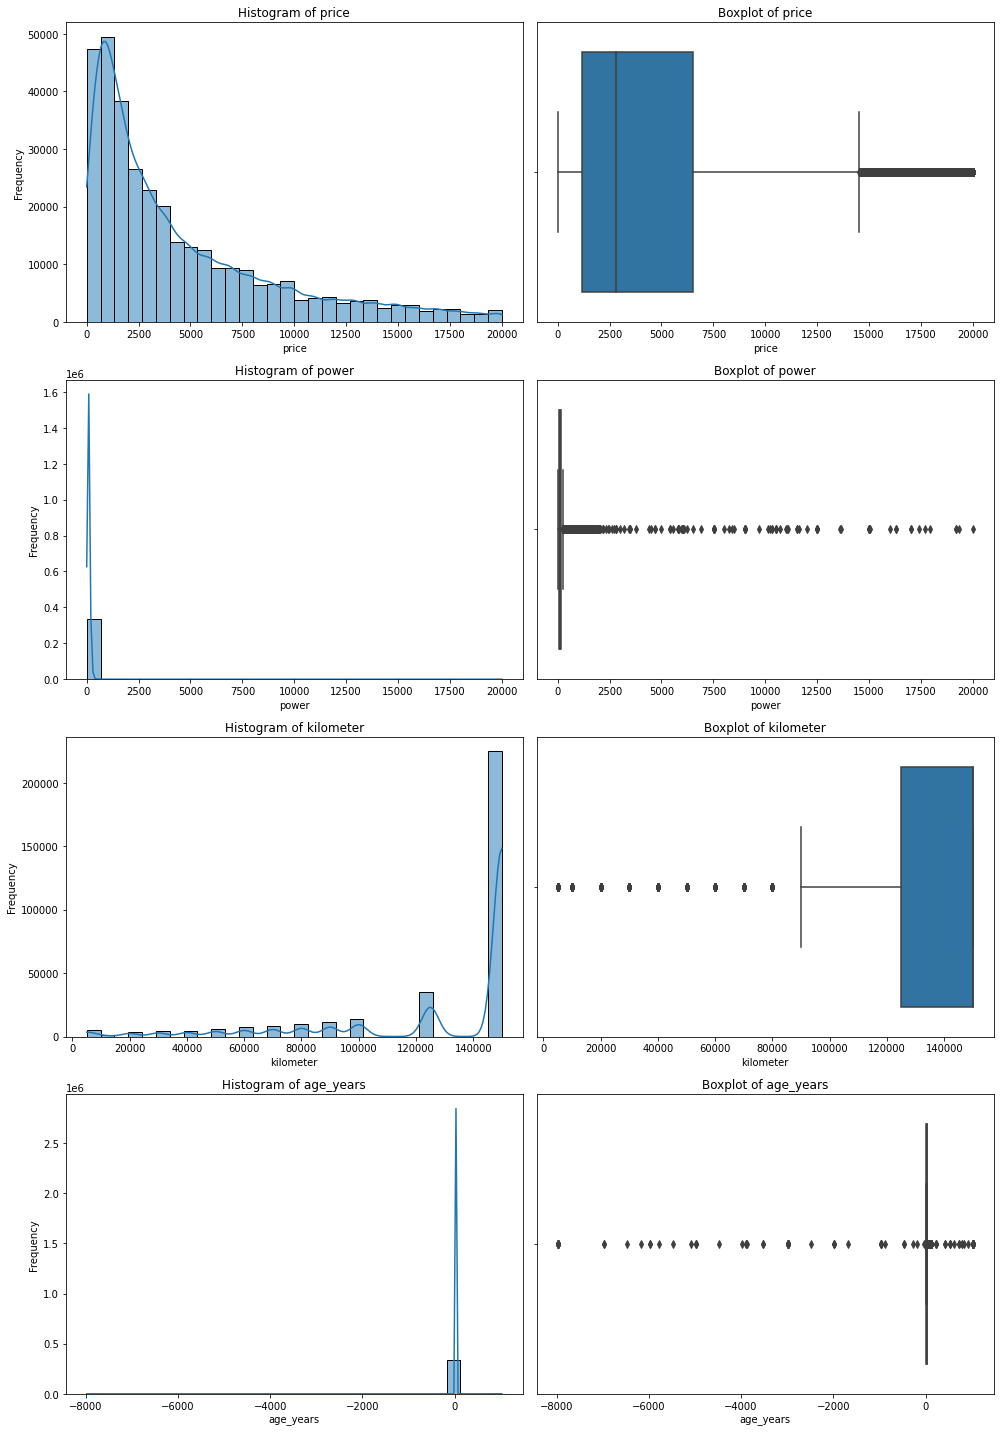

In [36]:
# построим график для количественных данных
#определим количество строк и столбцов для подграфиков 
num_features = len(quantitative_columns)
fig, axes = plt.subplots(nrows=num_features, ncols=2, figsize=(14, num_features * 5))
for i, column in enumerate(quantitative_columns):
    #построим гистограмму 
    sns.histplot(data[column], bins = 30, kde = True, ax=axes[i,0])
    axes[i,0].set_title(f'Histogram of {column}')
    axes[i,0].set_xlabel(column)
    axes[i,0].set_ylabel('Frequency')
    #построим боксплот
    sns.boxplot( x=data[column], ax=axes[i,1])
    axes[i,1].set_title(f'Boxplot of {column}')
    axes[i,1].set_xlabel(column)
plt.tight_layout()
plt.show()

In [37]:
data.query('power ==0').head(30)

,date_crawled,price,vehicle_type,registration_year,gearbox,power,model,kilometer,registration_month,fuel_type,brand,repaired,date_created,number_of_pictures,postal_code,last_seen,postal_region,age_years,age_category
0,2016-03-24 11:52:17,480,sedan,1993,manual,0,golf,150000,0,gasoline,volkswagen,unknown,2016-03-24,0,70435,2016-04-07 03:16:57,70,31,Super-Retro
14,2016-03-11 21:39:15,450,small,1910,manual,0,ka,5000,0,gasoline,ford,unknown,2016-03-11,0,24148,2016-03-19 08:46:47,24,114,Super-Retro
31,2016-03-15 20:59:01,245,sedan,1994,manual,0,golf,150000,2,gasoline,volkswagen,no,2016-03-15,0,44145,2016-03-17 18:17:43,44,30,Super-Retro
36,2016-03-28 17:50:15,1500,bus,2016,manual,0,kangoo,150000,1,gasoline,renault,no,2016-03-28,0,46483,2016-03-30 09:18:02,46,8,Old
39,2016-03-26 22:06:17,0,small,1990,manual,0,corsa,150000,1,gasoline,opel,unknown,2016-03-26,0,56412,2016-03-27 17:43:34,56,34,Super-Retro
53,2016-03-17 07:56:40,4700,wagon,2005,manual,0,signum,150000,0,gasoline,opel,no,2016-03-17,0,88433,2016-04-04 04:17:32,88,19,Retro
54,2016-03-26 10:39:35,550,wagon,1999,manual,0,astra,150000,8,gasoline,opel,yes,2016-03-26,0,56759,2016-04-01 23:17:27,56,25,Retro
67,2016-04-01 11:56:40,1200,coupe,2001,manual,0,astra,150000,0,gasoline,opel,unknown,2016-04-01,0,47249,2016-04-07 08:46:07,47,23,Retro
68,2016-03-08 01:36:42,800,small,1993,manual,0,polo,150000,3,gasoline,volkswagen,no,2016-03-08,0,8258,2016-04-05 23:46:00,82,31,Super-Retro
87,2016-03-23 11:53:21,2400,sedan,2003,manual,0,a4,150000,9,gasoline,audi,unknown,2016-03-23,0,40210,2016-03-23 11:53:21,40,21,Retro


In [38]:
data.query('power > 2000')

,date_crawled,price,vehicle_type,registration_year,gearbox,power,model,kilometer,registration_month,fuel_type,brand,repaired,date_created,number_of_pictures,postal_code,last_seen,postal_region,age_years,age_category
7263,2016-04-02 19:25:25,1499,small,1999,manual,7515,lupo,150000,4,gasoline,volkswagen,unknown,2016-04-02,0,65830,2016-04-06 11:46:49,65,25,Retro
10452,2016-03-25 19:55:32,0,sedan,1998,manual,10317,other,150000,8,gasoline,fiat,no,2016-03-25,0,57520,2016-04-01 19:16:33,57,26,Retro
18076,2016-03-20 17:54:04,9750,wagon,2005,auto,2729,5er,150000,7,gasoline,bmw,no,2016-03-20,0,21376,2016-03-23 02:48:53,21,19,Retro
23872,2016-03-28 19:57:39,10900,bus,2009,manual,10520,caddy,150000,6,gasoline,volkswagen,no,2016-03-28,0,36272,2016-04-07 02:47:02,36,15,Retro
32043,2016-03-09 11:37:03,3740,small,2006,manual,6920,aygo,90000,10,gasoline,toyota,no,2016-03-09,0,94116,2016-03-17 05:16:32,94,18,Retro
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
327373,2016-03-25 12:55:36,1300,sedan,2000,manual,12512,carisma,150000,9,gasoline,mitsubishi,unknown,2016-03-25,0,42105,2016-04-06 14:44:53,42,24,Retro
327420,2016-03-24 11:50:41,7498,sedan,2017,auto,2018,5er,150000,9,gasoline,bmw,no,2016-03-24,0,59425,2016-03-30 12:46:26,59,7,Old
328780,2016-03-16 21:48:39,850,sedan,1993,auto,9012,golf,150000,0,gasoline,volkswagen,unknown,2016-03-16,0,14482,2016-04-03 09:17:43,14,31,Super-Retro
328874,2016-04-04 12:38:11,3000,coupe,2007,manual,2007,corsa,150000,3,gasoline,opel,yes,2016-04-04,0,72218,2016-04-04 12:38:11,72,17,Retro


Исходя из полученных данных можно сказать, что у нас есть проблемы с данными по мощности автомобиля. Есть автомобили с мощностью = 0, что невозможно. Также есть неадекватно высокие значения мощности. Думаю, что можно удалить значения более 2000 лошадиных сил и значения, равные 0

In [39]:
data = data.query('power!= 0 & power < 2000')

In [40]:
data.query('power==0')

,date_crawled,price,vehicle_type,registration_year,gearbox,power,model,kilometer,registration_month,fuel_type,brand,repaired,date_created,number_of_pictures,postal_code,last_seen,postal_region,age_years,age_category


In [41]:
data.query('power>2000')

,date_crawled,price,vehicle_type,registration_year,gearbox,power,model,kilometer,registration_month,fuel_type,brand,repaired,date_created,number_of_pictures,postal_code,last_seen,postal_region,age_years,age_category


Также, есть автомобили со стоимостью = 0

Хотя на некоторых сайтах действительно можно встретить объявления с ценами 0 или 1 евро, такие данные могут искажать результаты модели, особенно если их немного и они, вероятно, являются ошибками при заполнении формы или представлены неадекватно (например, автомобили на металлолом или с иными скрытыми условиями продажи).

Можно выявить аномально низкие значения и удалить их. Например, если медианная цена на подержанные автомобили составляет несколько тысяч евро, цены ниже 1-го или 5-го процентиля можно считать "подозрительно" низкими.

In [42]:
#найдем 5-ый процентиль
lower_bound = data['price'].quantile(0.05)

In [43]:
lower_bound

300.0

In [44]:
#установим ограничения для данных, что б они были выше этого 5-го процентиля
data = data.query(f'price >= {lower_bound}')

In [45]:
#проверим
data.query('price<300')

,date_crawled,price,vehicle_type,registration_year,gearbox,power,model,kilometer,registration_month,fuel_type,brand,repaired,date_created,number_of_pictures,postal_code,last_seen,postal_region,age_years,age_category


Также есть странные данные в столбце age_years. У нас есть данные, где возраст отрицательный. Посмотрим на них:

In [46]:
data.query('age_years<0')

,date_crawled,price,vehicle_type,registration_year,gearbox,power,model,kilometer,registration_month,fuel_type,brand,repaired,date_created,number_of_pictures,postal_code,last_seen,postal_region,age_years,age_category
44126,2016-03-12 07:36:23,5000,small,2900,manual,120,corsa,5000,9,gasoline,opel,unknown,2016-03-12,0,9326,2016-04-05 23:18:26,93,-876,New
50693,2016-03-29 22:39:32,7999,sedan,5911,auto,75,golf,10000,0,gasoline,volkswagen,unknown,2016-03-29,0,41462,2016-04-06 09:17:09,41,-3887,New
59136,2016-04-04 15:59:21,12000,sedan,4000,manual,500,golf,5000,0,gasoline,volkswagen,no,2016-04-04,0,57392,2016-04-06 18:16:58,57,-1976,New
75430,2016-03-20 18:56:44,9000,sedan,5000,manual,420,impreza,5000,6,gasoline,subaru,no,2016-03-20,0,34253,2016-04-07 02:45:30,34,-2976,New
117889,2016-04-03 10:48:45,1500,bus,5000,manual,174,other,5000,0,gasoline,volkswagen,unknown,2016-04-03,0,48167,2016-04-07 11:46:18,48,-2976,New
216988,2016-03-22 12:46:06,1200,small,5000,manual,146,other,5000,0,gasoline,fiat,unknown,2016-03-22,0,83454,2016-04-06 01:16:33,83,-2976,New
292571,2016-03-30 20:51:45,11500,sedan,5000,manual,110,kadett,5000,0,gasoline,opel,unknown,2016-03-30,0,91352,2016-03-30 20:51:45,91,-2976,New
302577,2016-03-16 07:54:37,500,wagon,8200,auto,81,octavia,10000,11,gasoline,skoda,unknown,2016-03-16,0,30559,2016-03-16 08:52:33,30,-6176,New
304277,2016-03-24 17:56:29,15000,sedan,5000,manual,155,golf,5000,5,gasoline,volkswagen,unknown,2016-03-24,0,38302,2016-04-07 11:16:25,38,-2976,New
308364,2016-03-29 21:36:16,7999,sedan,5911,auto,75,golf,10000,0,gasoline,volkswagen,unknown,2016-03-29,0,41462,2016-04-06 07:46:20,41,-3887,New


Также есть данные, где возраст автомобиля составляет более 100 лет

In [47]:
data.query('age_years>100')

,date_crawled,price,vehicle_type,registration_year,gearbox,power,model,kilometer,registration_month,fuel_type,brand,repaired,date_created,number_of_pictures,postal_code,last_seen,postal_region,age_years,age_category
17261,2016-03-09 17:49:44,7999,sedan,1500,manual,224,impreza,5000,3,gasoline,subaru,unknown,2016-03-09,0,53577,2016-03-15 05:15:17,53,524,Super-Retro
22468,2016-03-16 19:58:34,3900,wagon,1910,manual,90,passat,150000,0,gasoline,volkswagen,unknown,2016-03-16,0,88662,2016-04-07 05:45:53,88,114,Super-Retro
53090,2016-03-30 18:54:27,950,sedan,1400,manual,1400,golf,125000,4,gasoline,volkswagen,unknown,2016-03-30,0,50389,2016-04-03 09:45:19,50,624,Super-Retro
59296,2016-03-07 22:58:46,3400,small,1910,manual,90,beetle,90000,4,gasoline,volkswagen,no,2016-03-07,0,34308,2016-03-12 08:16:51,34,114,Super-Retro
70624,2016-03-21 12:52:05,400,sedan,1910,manual,60,golf,150000,0,gasoline,volkswagen,unknown,2016-03-21,0,29462,2016-03-25 09:17:54,29,114,Super-Retro
110859,2016-03-14 14:00:30,8750,convertible,1923,manual,11,c3,5000,0,gasoline,citroen,no,2016-03-14,0,27299,2016-04-05 16:44:28,27,101,Super-Retro
135647,2016-03-17 23:40:11,550,sedan,1000,manual,1000,golf,5000,6,gasoline,volkswagen,unknown,2016-03-17,0,91732,2016-03-26 05:18:19,91,1024,Super-Retro
191847,2016-04-01 15:37:14,400,sedan,1910,manual,170,3er,5000,0,gasoline,bmw,unknown,2016-04-01,0,66333,2016-04-03 11:48:08,66,114,Super-Retro
206028,2016-03-16 12:46:55,7999,sedan,1800,manual,290,golf,5000,6,gasoline,volkswagen,unknown,2016-03-16,0,15827,2016-03-29 20:47:40,15,224,Super-Retro
211390,2016-03-20 07:37:16,1500,bus,1910,manual,999,espace,150000,0,gasoline,renault,unknown,2016-03-20,0,24873,2016-04-06 04:45:40,24,114,Super-Retro


Если рассматривать только современное производство, то минимальные годы, которые обычно учитываются в автомобильной индустрии, начинаются с конца XIX века (1900 год). Можем взять за основу эту дату

In [48]:
#уберем автомобили с указанными выше проблемами в данных
data = data.query('age_years>= 0 & age_years < 124')

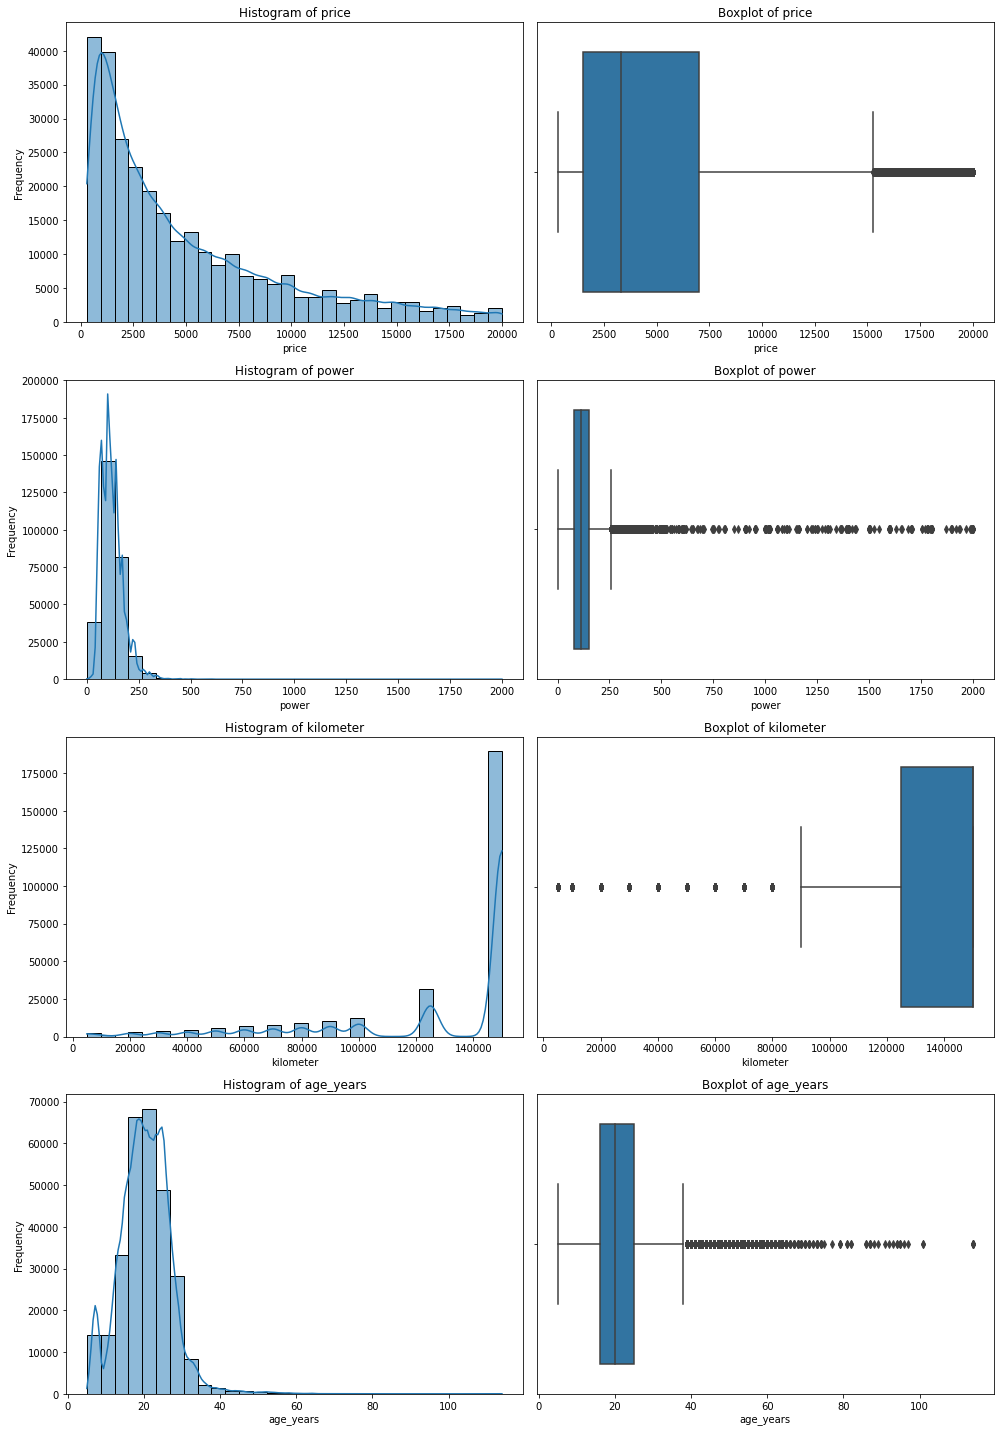

In [49]:
# построим график для количественных данных
#определим количество строк и столбцов для подграфиков 
num_features = len(quantitative_columns)
fig, axes = plt.subplots(nrows=num_features, ncols=2, figsize=(14, num_features * 5))
for i, column in enumerate(quantitative_columns):
    #построим гистограмму 
    sns.histplot(data[column], bins = 30, kde = True, ax=axes[i,0])
    axes[i,0].set_title(f'Histogram of {column}')
    axes[i,0].set_xlabel(column)
    axes[i,0].set_ylabel('Frequency')
    #построим боксплот
    sns.boxplot( x=data[column], ax=axes[i,1])
    axes[i,1].set_title(f'Boxplot of {column}')
    axes[i,1].set_xlabel(column)
plt.tight_layout()
plt.show()

In [50]:
#посмотрим на обновленный датафрейм
data.head(5)

,date_crawled,price,vehicle_type,registration_year,gearbox,power,model,kilometer,registration_month,fuel_type,brand,repaired,date_created,number_of_pictures,postal_code,last_seen,postal_region,age_years,age_category
1,2016-03-14 12:52:21,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,unknown,2016-03-14,0,90480,2016-04-05 12:47:46,90,20,Retro
2,2016-03-17 16:54:04,1500,small,2001,manual,75,golf,150000,6,gasoline,volkswagen,no,2016-03-17,0,91074,2016-03-17 17:40:17,91,23,Retro
3,2016-03-31 17:25:20,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,2016-03-31,0,60437,2016-04-06 10:17:21,60,16,Retro
4,2016-04-04 17:36:23,650,sedan,1995,manual,102,3er,150000,10,gasoline,bmw,yes,2016-04-04,0,33775,2016-04-06 19:17:07,33,29,Retro
5,2016-04-01 20:48:51,2200,convertible,2004,manual,109,2_reihe,150000,8,gasoline,peugeot,no,2016-04-01,0,67112,2016-04-05 18:18:39,67,20,Retro


In [51]:
#напишем функцию для построения гистограммы для каждого категориального признака и дескретных значений
#сначала укажем, какие признаки у нас относятся к категориальным и дискретным значениям
categorical_disc_columns = ['vehicle_type','gearbox', 'model', 'fuel_type', 'brand', 'repaired', 'registration_month', 'postal_region', 'age_category']

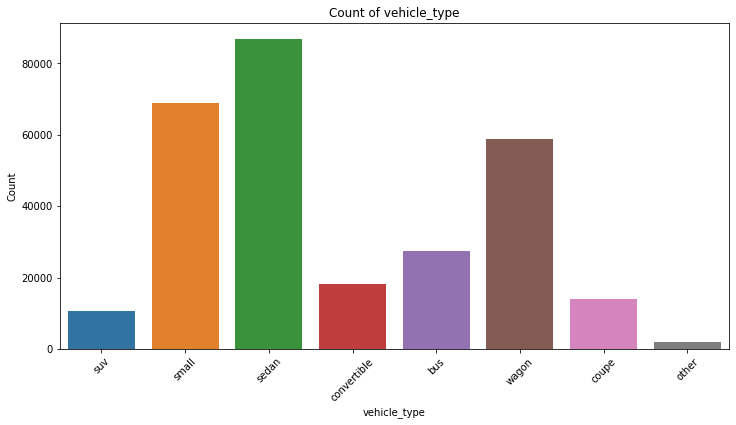

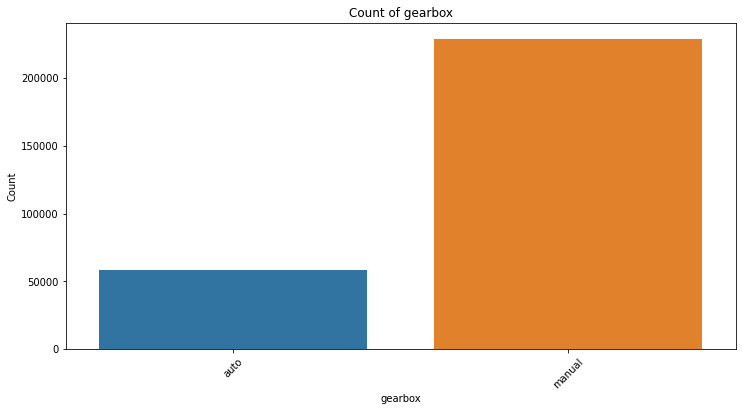

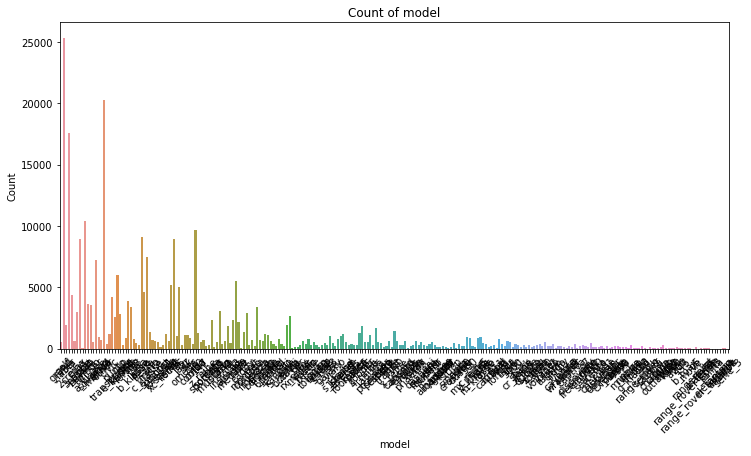

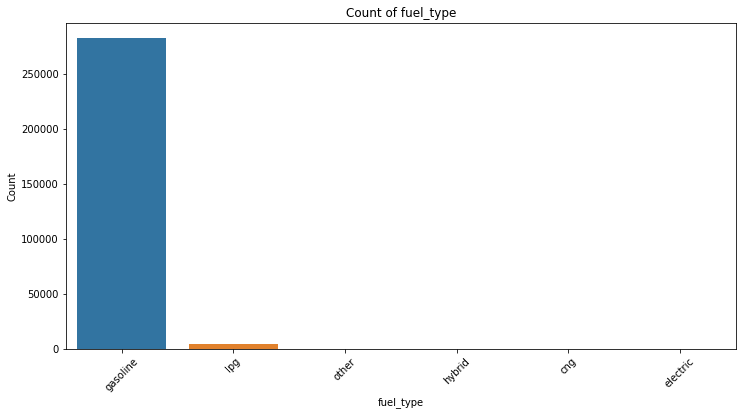

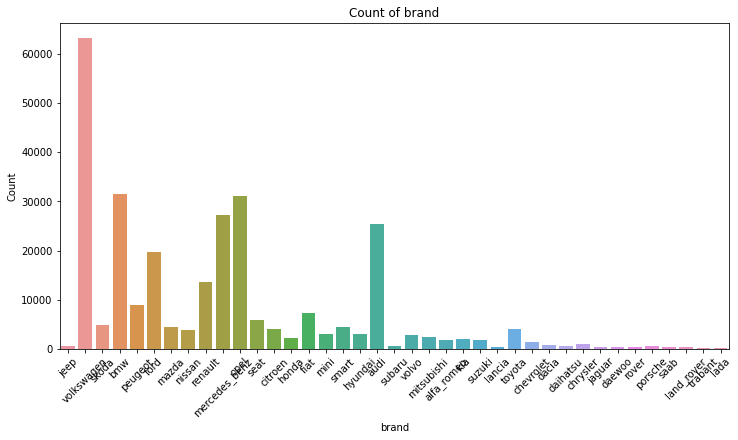

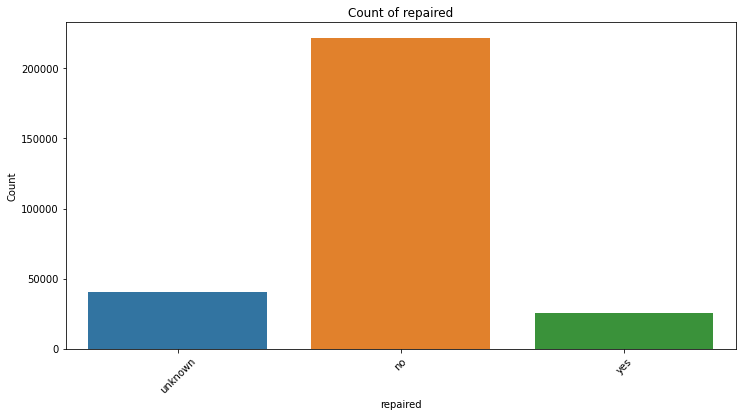

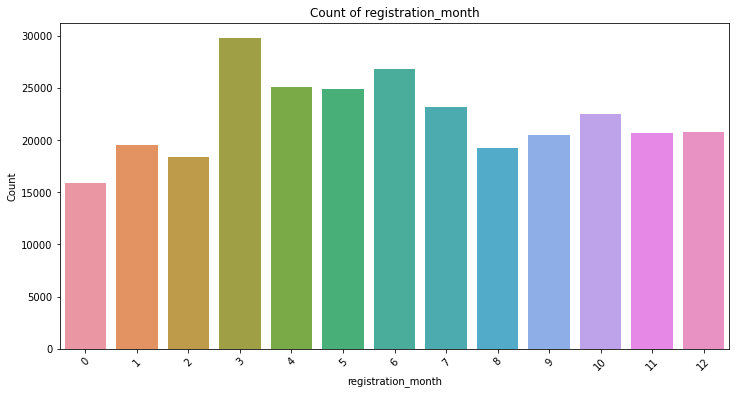

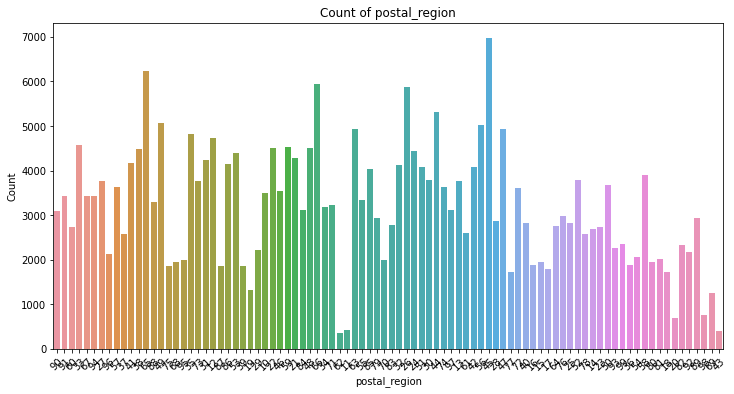

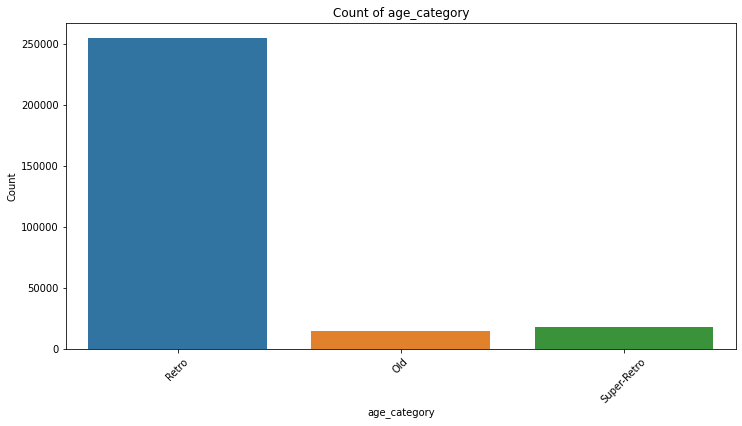

In [52]:
#напишем функцию для построения графиков для категориальных данных датасета 
for column in categorical_disc_columns:
    plt.figure(figsize=(12, 6))
    sns.countplot(x=column, data=data)
    plt.title(f'Count of {column}')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

Согласно графику, fuel type в основном представлен только типом gasoline, в то время как других категорий практически нет, что будет неинформативным. 

В датасете представлены в основном старые и ретро автомобили, новых (срок службы до 3 лет) нет. Самые "молодые" автомобили это автомобили от 2019 года

удалим неинформативные столбцы из дальнейшего анализа 

In [53]:
data = data.drop(columns=['number_of_pictures', 'date_created', 'postal_code', 'date_crawled', 'last_seen', 'fuel_type'])

### Корреляционный анализ 

Далее проведем корреляционный анализ

In [54]:
#укажем список непрерывных признаков
interval_cols = ['price', 'power']

In [55]:
# построим матрицу корреляций в том числе и для категориальных признаков с помощью phik_matrix() 
data.phik_matrix(interval_cols=interval_cols) 

,price,vehicle_type,registration_year,gearbox,power,model,kilometer,registration_month,brand,repaired,postal_region,age_years,age_category
price,1.000000,0.262239,0.671517,0.319846,0.342366,0.573220,0.329712,0.113746,0.329205,0.305689,0.121480,0.671517,0.158123
vehicle_type,0.262239,1.000000,0.286190,0.274177,0.180202,0.922666,0.196397,0.076590,0.609123,0.084303,0.114197,0.286190,0.199619
registration_year,0.671517,0.286190,1.000000,0.132246,0.202503,0.671540,0.647482,0.211955,0.364691,0.351196,0.132468,1.000000,1.000000
gearbox,0.319846,0.274177,0.132246,1.000000,0.454648,0.652498,0.025570,0.046893,0.503592,0.020872,0.156859,0.132246,0.025414
power,0.342366,0.180202,0.202503,0.454648,1.000000,0.500469,0.046915,0.029208,0.315985,0.051284,0.056497,0.202503,0.048573
model,0.573220,0.922666,0.671540,0.652498,0.500469,1.000000,0.444804,0.156859,0.998404,0.205546,0.313614,0.671540,0.557245
kilometer,0.329712,0.196397,0.647482,0.025570,0.046915,0.444804,1.000000,0.095175,0.286199,0.175511,0.095084,0.647482,0.172860
registration_month,0.113746,0.076590,0.211955,0.046893,0.029208,0.156859,0.095175,1.000000,0.090359,0.304767,0.085042,0.211955,0.185377
brand,0.329205,0.609123,0.364691,0.503592,0.315985,0.998404,0.286199,0.090359,1.000000,0.122975,0.223089,0.364691,0.275557
repaired,0.305689,0.084303,0.351196,0.020872,0.051284,0.205546,0.175511,0.304767,0.122975,1.000000,0.095697,0.351196,0.345054


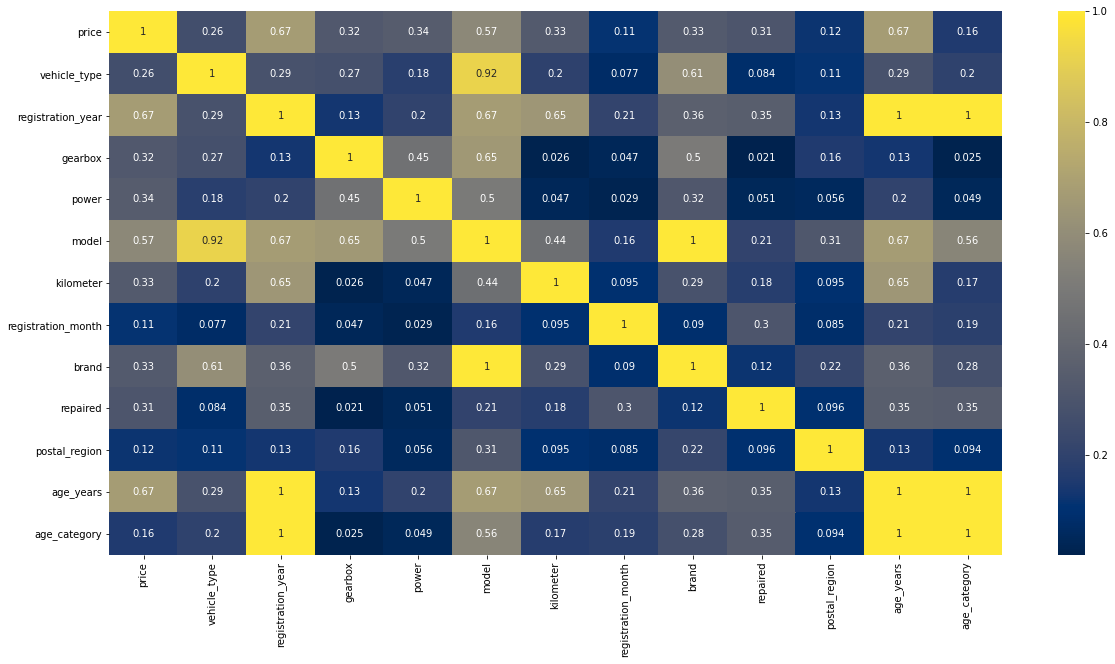

In [56]:
#визуализируем полученную матрицу
plt.figure(figsize=(20,10))
sns.heatmap(data.phik_matrix(interval_cols=interval_cols), annot=True, cmap='cividis');

Можно отметить следующие ключевые наблюдения данной корреляционной матрицы

Сильные корреляции:
price (стоимость автомобиля) имеет сильную положительную корреляцию с: 1) registration_year (0.68), что логично, поскольку данный признак указывает сколько лет данному автомобилю. 2) моделью машины (model) (0.58) 3) мощностью двигателя (power) (0.35) 4) фактом о том была ли машина в ремонте (repaired) (0.34) 5) брендом автомобиля (brand)(0.33) 6) пробегом автомобиля (kilometer) (0.32) и 6) типом коробки передач (gearbox) (0.32).

Слабые или незначительные корреляции с : 1) типом кузова (vehicle_type) (0.27). 2) Очень слабая положительная связь между стоимостью автомобиля и месяцем регистрации автомобиля. 3) с почтовым индексом региона (0.13). 
Почти нулевые значения корреляции с типом  топлива (fuel_type) (0.045)

Что бы избежать мультиколлинеарности между столбцами brand и model, мы просто объединим 2 столбца model и brand в один

In [57]:
data['auto_name'] = data['brand'] + ' ' + data['model']

In [58]:
data.head(2)

,price,vehicle_type,registration_year,gearbox,power,model,kilometer,registration_month,brand,repaired,postal_region,age_years,age_category,auto_name
1,9800,suv,2004,auto,163,grand,125000,8,jeep,unknown,90,20,Retro,jeep grand
2,1500,small,2001,manual,75,golf,150000,6,volkswagen,no,91,23,Retro,volkswagen golf


In [59]:
data= data.drop(columns=['model', 'brand'])

In [60]:
data.head(2)

,price,vehicle_type,registration_year,gearbox,power,kilometer,registration_month,repaired,postal_region,age_years,age_category,auto_name
1,9800,suv,2004,auto,163,125000,8,unknown,90,20,Retro,jeep grand
2,1500,small,2001,manual,75,150000,6,no,91,23,Retro,volkswagen golf


Из 'registration_year', 'age_year' и 'age_category' выберем одну для дальнейшего анализа, что бы избежать мультиколлинеарности.

In [61]:
data = data.drop(columns=['age_category', 'registration_year'])

In [62]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 287329 entries, 1 to 334659
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   price               287329 non-null  int64 
 1   vehicle_type        287329 non-null  object
 2   gearbox             287329 non-null  object
 3   power               287329 non-null  int64 
 4   kilometer           287329 non-null  int64 
 5   registration_month  287329 non-null  int64 
 6   repaired            287329 non-null  object
 7   postal_region       287329 non-null  object
 8   age_years           287329 non-null  int64 
 9   auto_name           287329 non-null  object
dtypes: int64(5), object(5)
memory usage: 32.2+ MB


Расчёт VIF помогает определить, насколько степень корреляции между признаками может повлиять на устойчивость модели. Значения VIF выше 10 (или иногда 5) указывают на значительную мультиколлинеарность.

In [63]:
quantitative_columns = ['price', 'power', 'kilometer', 'registration_month', 'age_years']

In [64]:
# удалим нечисловые столбцы
numeric_data = data[quantitative_columns].copy()

In [65]:
numeric_data.head(2)

,price,power,kilometer,registration_month,age_years
1,9800,163,125000,8,20
2,1500,75,150000,6,23


In [66]:
# добавим константы для расчета VIF
X = add_constant(numeric_data)

In [67]:
#вычислим VIF
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

In [68]:
vif_data

,feature,VIF
0,const,34.639023
1,price,1.852097
2,power,1.368515
3,kilometer,1.328389
4,registration_month,1.003604
5,age_years,1.277734


C данными все в порядке, мультиколлинеарность отсутствует

Проверим еще раз дубликаты

In [69]:
data.duplicated().sum()

20767

Похоже, у нас выявлено целых 20767 дубликата. Проверим

In [70]:
#выберем все строки, которые являются дубликатами, включая оригинальные строки
duplicate_rows = data[data.duplicated(keep=False)]
#отсортируем по всем столбцам, чтобы дубликаты шли подряд
duplicate_rows_sorted = duplicate_rows.sort_values(by=data.columns.tolist())
#выведем первые 10 строк для проверки
duplicate_rows_sorted.head(10)

,price,vehicle_type,gearbox,power,kilometer,registration_month,repaired,postal_region,age_years,auto_name
187655,300,coupe,auto,75,125000,4,yes,41,25,peugeot 2_reihe
192087,300,coupe,auto,75,125000,4,yes,41,25,peugeot 2_reihe
87876,300,coupe,auto,101,150000,0,no,45,28,opel astra
131145,300,coupe,auto,101,150000,0,no,45,28,opel astra
184564,300,coupe,auto,101,150000,0,no,45,28,opel astra
282397,300,coupe,auto,101,150000,0,no,45,28,opel astra
19328,300,coupe,manual,73,150000,10,no,37,24,mazda 3_reihe
27965,300,coupe,manual,73,150000,10,no,37,24,mazda 3_reihe
92080,300,coupe,manual,90,150000,5,no,93,30,opel tigra
142236,300,coupe,manual,90,150000,5,no,93,30,opel tigra


Действительно, полные дубликаты. Удалим их

In [71]:
data = data.drop_duplicates()

In [72]:
#проверим
data.duplicated().sum()

0

## Обучение моделей

In [73]:
RANDOM_STATE = 42
TEST_SIZE = 0.25
#разделим наши данные на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    data.drop(['price'], axis=1),
    data['price'],
    test_size = TEST_SIZE, 
    random_state = RANDOM_STATE)
X_train.shape, X_test.shape

((199921, 9), (66641, 9))

In [74]:
data.head(2)

,price,vehicle_type,gearbox,power,kilometer,registration_month,repaired,postal_region,age_years,auto_name
1,9800,suv,auto,163,125000,8,unknown,90,20,jeep grand
2,1500,small,manual,75,150000,6,no,91,23,volkswagen golf


Далее обозначим, какие данные требуют масштабирования, а какие — кодирования.

Признаки vehicle_type, gearbox,  auto_name, 'postal_region', 'repaired'  мы закодируем с помощью OrdinalEncoder

LightGBM умеет напрямую работать с категориальными признаками, что избавляет нас от необходимости их предварительного кодирования с использованием one-hot или ordinal encoding. Если бы мы использовали только LightGBM, то можно было бы не кодировать категориальные признаки.

In [75]:
# создаём списки с названиями признаков
ord_columns = ['vehicle_type', 'gearbox', 'auto_name', 'postal_region', 'repaired']  

In [76]:
num_columns = ['age_years', 'power', 'kilometer', 'registration_month']

In [77]:
# создаём пайплайн для подготовки признаков из списка ord_columns: заполнение пропусков и ord-кодирование
# SimpleImputer + ordinal
ordinal_pipe = Pipeline(
    [
        ('simpleImputer_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
        ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
    ]
)

In [78]:
# Предобработка для DecisionTreeRegressor
preprocessor_dt = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_columns),
        ('cat', ordinal_pipe, ord_columns)
    ]
)

# соберем пайплайн для DecisionTreeRegressor
pipeline_dt = Pipeline(steps=[
    ('preprocessor', preprocessor_dt),
    ('models', DecisionTreeRegressor(random_state=42))
])

# рассмотрим гиперпараметры для DecisionTreeRegressor
param_grid_dt = {
        'models': [DecisionTreeRegressor(random_state=42)],
        'models__max_depth': range(1, 10),
        'models__max_features': range(1, len(num_columns) + len(ord_columns) + 1),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
}
# RandomizedSearchCV для DecisionTreeRegressor
random_search_dt = RandomizedSearchCV(pipeline_dt, param_grid_dt, cv=5, scoring='neg_mean_squared_error', return_train_score=True)
random_search_dt.fit(X_train, y_train)

# получим результаты кросс-валидации
cv_results_dt = random_search_dt.cv_results_

# извлечем среднее время обучения и предсказания
mean_fit_time_dt = np.mean(cv_results_dt['mean_fit_time'])
mean_score_time_dt = np.mean(cv_results_dt['mean_score_time'])

# определим лучшую модель для DecisionTreeRegressor
best_model_dt = random_search_dt.best_estimator_

# вычислим RMSE 
# Выбираем лучшее значение отрицательной MSE (наименьшее по модулю, т.к. они отрицательные)
best_neg_mse_dt = random_search_dt.best_score_  
# вычисляем RMSE
best_rmse_dt = np.sqrt(-best_neg_mse_dt)

In [80]:
# соберем пайплайн для LGBMRegressor
pipeline_lgbm = Pipeline(steps=[
    ('preprocessor', 'passthrough'),  
    ('model', LGBMRegressor(random_state=42))
])
# Перед использованием модели LGBM, помечаем категориальные данные
X_train[ord_columns] = X_train[ord_columns].astype('category')

# рассмотрим гиперпараметры для LGBMRegressor
param_grid_lgbm = {
    'model__max_depth': range(3, 10),
    'model__learning_rate': np.arange(0.01, 0.3, 0.01),
    'model__n_estimators': range(50, 300, 50)
}
# RandomizedSearchCV для LGBMRegressor
random_search_lgbm = RandomizedSearchCV(pipeline_lgbm, param_grid_lgbm, cv=5, scoring='neg_mean_squared_error', return_train_score=True)
random_search_lgbm.fit(X_train, y_train)

# получим результаты кросс-валидации
cv_results_lgbm = random_search_lgbm.cv_results_

# извлечем среднее время обучения и предсказания
mean_fit_time_lgbm = np.mean(cv_results_lgbm['mean_fit_time'])
mean_score_time_lgbm = np.mean(cv_results_lgbm['mean_score_time'])

#определим лучшую модель для LGBMRegressor
best_model_lgbm = random_search_lgbm.best_estimator_

# вычислим RMSE 
# Выбираем лучшее значение отрицательной MSE (наименьшее по модулю, т.к. они отрицательные)
best_neg_mse_lgbm = random_search_lgbm.best_score_  
# вычисляем RMSE
best_rmse_lgbm = np.sqrt(-best_neg_mse_lgbm)

## Анализ моделей

In [81]:
#соберем таблицу с результатами
results = pd.DataFrame({
    'Models': ['Decision Tree', 'LGBM'],
    'Training Time (s)': [mean_fit_time_dt, mean_fit_time_lgbm],
    'Prediction Time (s)': [mean_score_time_dt, mean_score_time_lgbm],
    'RMSE': [best_rmse_dt, best_rmse_lgbm]
})

# Отобразим полученную таблицу результатов
print(results)

          Models  Training Time (s)  Prediction Time (s)         RMSE
0  Decision Tree           0.751845             0.111922  2040.171049
1           LGBM           4.669597             0.481715  1623.712872


Модель Decision Tree обучается быстрее, чем LGBM. Decision Tree завершает обучение за 0.75 секунды, в то время как LGBM требует 4.66 секунд. По времени предсказания Decision Tree также оказывается быстрее, выполняя предсказания за 0.12 секунды против 0.48 секунд для LGBM. Средняя квадратичная ошибка (RMSE) является показателем точности предсказаний — чем меньше значение RMSE, тем лучше модель. В этом случае LGBM имеет меньшую RMSE (1623.73) по сравнению с Decision Tree (2173.26), что свидетельствует о более высоком качестве предсказаний у модели LGBM.

Если основным критерием является качество предсказания, то LGBM является лучшей моделью благодаря значительно более низкому RMSE.
Если важны время обучения и время предсказания, то Decision Tree превосходит LGBM по этим показателям, обеспечивая быстрый процесс обучения и предсказания.

Далее решила работать с моделью LGBM с параметрами learning_rate=0.18, max_depth=8, n_estimators=150

In [82]:
best_model_lgbm

Pipeline(steps=[('preprocessor', 'passthrough'),
                ('model',
                 LGBMRegressor(learning_rate=0.18000000000000002, max_depth=8,
                               n_estimators=150, random_state=42))])

In [83]:
# проверим работу лучшей модели LGBM на тестовой выборке
# рассчитаем прогноз на тестовой данных
X_test[ord_columns] = X_test[ord_columns].astype('category')
y_test_pred = random_search_lgbm.predict(X_test)
print(f'Метрика MSE на тестовой выборке: {mean_squared_error(y_test, y_test_pred)}')
print(f'Метрика RSME на тестовой выборке: {np.sqrt(mean_squared_error(y_test, y_test_pred))}')

Метрика MSE на тестовой выборке: 2532072.631651242
Метрика RSME на тестовой выборке: 1591.2487648545848


Результаты показали, что метрика среднеквадратичной ошибки (MSE) для модели LGBM составила 2532072, а корень из среднеквадратичной ошибки (RSME) равен 1591.41. Эти значения свидетельствуют о сравнительно хорошей точности модели при прогнозировании.

Далее сравним нашу лучшую модель с константной моделью 

In [84]:
#инициализируем DummyRegressor со стратегией 'mean'
dummy_model = DummyRegressor(strategy='mean')
dummy_model.fit(X_train, y_train)

#предскажем константную модель на тестовых данных
y_dummy_pred = dummy_model.predict(X_test)

#оценим качество константной модели
print(f'Метрика MSE на тестовой выборке: {mean_squared_error(y_test, y_dummy_pred )}')
print(f'Метрика RSME на тестовой выборке: {np.sqrt(mean_squared_error(y_test, y_dummy_pred ))}')

Метрика MSE на тестовой выборке: 21036637.970846962
Метрика RSME на тестовой выборке: 4586.571483237448


Наша лучшая модель значительно превосходит константную модель, что подтверждает, что все усилия по созданию новых признаков, тюнингу и кросс-валидации оправданы. Это также подтверждает, что наша модель вносит существенный вклад в улучшение качества предсказаний по сравнению с простым подходом.

Далее проведем анализ остатков.

In [85]:
# Предсказанные значения на тестовой выборке
y_test_pred = random_search_lgbm.best_estimator_.predict(X_test)
residuals = y_test - y_test_pred

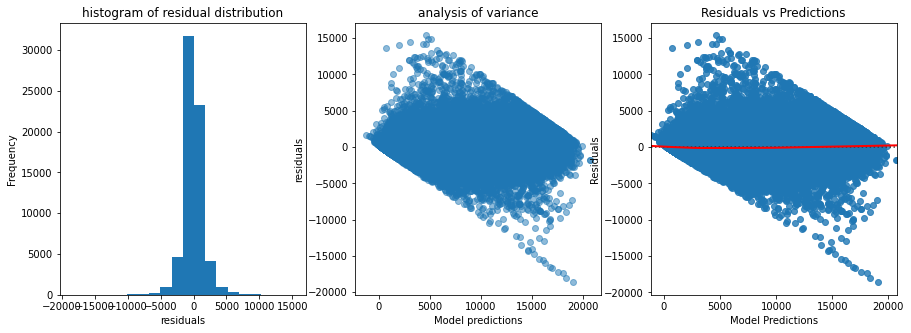

In [86]:
#Построим графики по количественным признакам - гистограмму частотности
#распределения и диаграмму рассеяния
fig, axes = plt.subplots(nrows = 1, ncols= 3, figsize = (15, 5))

axes[0].hist(residuals, bins = 20)
axes[0].set_title('histogram of residual distribution')
axes[0].set_xlabel('residuals')
axes[0].set_ylabel('Frequency')

axes[1].scatter(y_test_pred, residuals, alpha = 0.5)
axes[1].set_xlabel('Model predictions')
axes[1].set_ylabel('residuals')
axes[1].set_title('analysis of variance')

# sns.residplot для оценки распределения остатков 
sns.residplot(x=y_test_pred, y=residuals, lowess=True, ax=axes[2], line_kws={'color': 'red', 'lw': 2})
axes[2].set_title('Residuals vs Predictions')
axes[2].set_xlabel('Model Predictions')
axes[2].set_ylabel('Residuals')

plt.show()

Остатки модели не только показывают разницу между предсказанным и истинным значениями. Они также отражают закономерности, которые позволяют судить о качестве модели. Анализ остатков проверяет не решения модели, а то, насколько хорошо она замечает взаимосвязи между признаками. Если она не справляется с этим, то уже не важно, близки ли её предсказания к исходным значениям. Модель будет работать нестабильно.
Если посмотрим на график распределения остатков (график слева), то он показывает симметричное распределение. Если посмотрим на диаграмму рассеяния (2 графика справа) остатков в зависимости от прогнозных значений модели, то отметим, что линия, полученная с помощью lowess, практически прямая, но с небольшим искривлением, это указывает на то, что остатки модели в целом распределены нормально, но возможны незначительные отклонения в зависимости от предсказанных значений. 

# Вывод

В рамках проекта для сервиса по продаже автомобилей с пробегом «Не бит, не крашен» была поставлена задача разработки модели для определения рыночной стоимости автомобилей. Основными критериями заказчика были качество предсказания, время обучения и время предсказания модели. Для решения задачи были предоставлены данные с техническими характеристиками, комплектацией и ценами автомобилей, которые использовались для построения модели.
В ходе работы над проектом была применена стратегия подбора гиперпараметров с помощью RandomizedSearchCV для двух моделей: DecisionTreeRegressor и LGBMRegressor. Для подготовки данных использовался пайплайн, включающий OrdinalEncoder для категориальных признаков и MinMaxScaler для числовых. На основе данных были выбраны лучшие параметры для каждой из моделей, и модель LGBMRegressor с параметрами learning_rate=0.18, max_depth=8, n_estimators=150 показала наилучшие результаты.
При обучении и оценке моделей были получены следующие результаты:
Модель Decision Tree обучается быстрее, чем LGBM. Decision Tree завершает обучение за 0.75 секунды, в то время как LGBM требует 4.66 секунд. По времени предсказания Decision Tree также оказывается быстрее, выполняя предсказания за 0.12 секунды против 0.48 секунд для LGBM. Средняя квадратичная ошибка (RMSE) является показателем точности предсказаний — чем меньше значение RMSE, тем лучше модель. В этом случае LGBM имеет меньшую RMSE (1623.73) по сравнению с Decision Tree (2173.26), что свидетельствует о более высоком качестве предсказаний у модели LGBM.
Таким образом, если основным критерием является качество предсказания, то LGBM является лучшей моделью благодаря значительно более низкому RMSE. Однако, если важны время обучения и время предсказания, то Decision Tree превосходит LGBM по этим показателям, обеспечивая быстрый процесс обучения и предсказания.